✅ Daily precip–water-level merged: (125, 3)


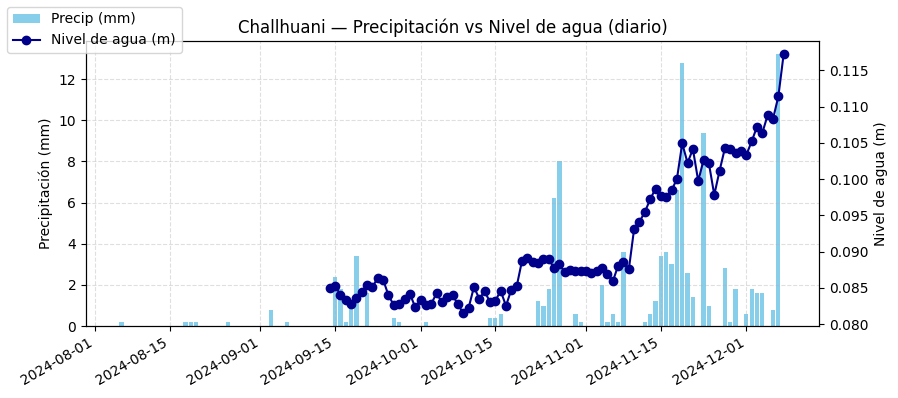

In [2]:
# =====================================================
# 0️⃣  Imports & verified daily preprocessing (your code)
# =====================================================
import pandas as pd, numpy as np, re, glob, os
import matplotlib.pyplot as plt
import rasterio, rioxarray as rxr, xarray as xr
from pathlib import Path

# -----------------------------
# File paths
# -----------------------------
S1_DIR = r"G:\Mi unidad\GEE_Biweekly_S1"
S2_DIR = r"G:\Mi unidad\GEE_Biweekly_S2"
CLIMATE_XLSX = r"precipitation_waterlevel\01 Data Climatic variables in the Challhuani.xlsx"
WLEVEL_XLSX  = r"precipitation_waterlevel\01_Data_ Water Level of Hydrological Stations.xlsx"
FLOW_ACC = r"E:\Hackathon_Picotani_datos_E\7_Chall\hydro_outputs\flow_acc.tif"

# -----------------------------
# Helpers (include your verified ones)
# -----------------------------
def fix_decimal(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace('\u00a0', ' ').replace(',', '.')
    if s == '' or s.lower() in {'na','nan','none'}: return np.nan
    try: return float(s)
    except: return np.nan

def parse_date_flexible(series):
    s = series.astype(str).str.strip().str.replace('\u00a0',' ',regex=False)
    s = s.str.replace(r'\s*/\s*','/',regex=True)
    return pd.to_datetime(s, errors='coerce')

# ---- Climate ----
clim = pd.read_excel(CLIMATE_XLSX, dtype=str)
clim.columns = [c.strip().replace('\u00a0',' ') for c in clim.columns]
clim['Date'] = parse_date_flexible(clim['Date'])
clim['Precipitation_mm'] = clim['Precipitation_mm'].apply(fix_decimal)
clim['date'] = pd.to_datetime(clim['Date'].dt.date)
clim_daily = (
    clim.dropna(subset=['date'])
        .groupby('date',as_index=False)['Precipitation_mm']
        .sum()
        .rename(columns={'Precipitation_mm':'precip_mm'})
)

# ---- Water level ----
wlev = pd.read_excel(WLEVEL_XLSX, dtype=str)
wlev.columns = [c.strip().replace('\u00a0',' ') for c in wlev.columns]
wlev = wlev[wlev['Monitoring_site'].astype(str).str.strip().str.lower()=='challhuani']
wlev['Date'] = parse_date_flexible(wlev['Date'])
wlev['Water_level_m'] = wlev['Water_level_m'].apply(fix_decimal)
wlev['date'] = pd.to_datetime(wlev['Date'].dt.date)
wlev_daily = (
    wlev.dropna(subset=['date'])
         .groupby('date',as_index=False)['Water_level_m']
         .mean()
         .rename(columns={'Water_level_m':'water_level_m'})
)

# ---- Merge ----
daily = pd.merge(clim_daily, wlev_daily, on='date', how='outer').sort_values('date')
daily.to_csv('challhuani_daily_precip_waterlevel.csv', index=False)
print("✅ Daily precip–water-level merged:", daily.shape)

# quick dual-axis plot
fig, ax1 = plt.subplots(figsize=(9,4))
ax1.bar(daily['date'], daily['precip_mm'], color='skyblue', label='Precip (mm)')
ax1.set_ylabel('Precipitación (mm)')
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['water_level_m'], 'o-', color='darkblue', label='Nivel de agua (m)')
ax2.set_ylabel('Nivel de agua (m)')
fig.autofmt_xdate(); ax1.grid(True, linestyle='--', alpha=0.4)
fig.legend(loc='upper left'); plt.title("Challhuani — Precipitación vs Nivel de agua (diario)")
plt.tight_layout(); plt.show()


In [3]:
with rasterio.open(FLOW_ACC) as src:
    acc = src.read(1).astype(float)
    prof = src.profile
acc[acc<=0] = np.nan
ACC_THR = 2000                      # adjust if you want denser/sparser network
stream_mask = (acc > ACC_THR).astype('uint8')

mask_path = str(Path(FLOW_ACC).with_name("streams_main_mask.tif"))
with rasterio.open(mask_path,'w',driver='GTiff',
                   height=acc.shape[0],width=acc.shape[1],count=1,
                   dtype='uint8',crs=prof['crs'],transform=prof['transform']) as dst:
    dst.write(stream_mask,1)
print("✅ drainage mask saved:", mask_path)


✅ drainage mask saved: E:\Hackathon_Picotani_datos_E\7_Chall\hydro_outputs\streams_main_mask.tif


In [11]:
import rioxarray as rxr
import rasterio
from pathlib import Path
import re
def parse_date_from_name(fp):
    m = re.search(r'(\d{8})_S1', os.path.basename(fp))
    return pd.to_datetime(m.group(1),format='%Y%m%d') if m else None

s1_files = sorted(glob.glob(os.path.join(S1_DIR,"*_S1_Indices.tif")))
s1_dates = [parse_date_from_name(f) for f in s1_files]
vh_list=[]
for f,d in zip(s1_files,s1_dates):
    if d is None: continue
    da = rxr.open_rasterio(f)
    vh = da.isel(band=1).squeeze()     # band 2 (VH)
    vh = vh.assign_coords({"time":d}).expand_dims("time")
    vh = vh.rio.write_crs(da.rio.crs,inplace=True)
    vh_list.append(vh)
s1_vh = xr.concat(vh_list,dim="time").sortby("time")
vh_std = s1_vh.std(dim="time", skipna=True)
# Reload the mask and force the correct CRS
mask_da = rxr.open_rasterio(mask_path).squeeze()

# if it says LOCAL_CS, overwrite with EPSG:32719
mask_da = mask_da.rio.write_crs("EPSG:32719", inplace=True)

# Now reproject to the VH_STD grid
mask_on_s1 = mask_da.rio.reproject_match(vh_std)

# Convert to boolean mask
mask_on_s1 = mask_on_s1 > 0

print("MASK_ON_S1:", mask_on_s1.rio.crs, mask_on_s1.shape)


MASK_ON_S1: EPSG:32719 (782, 813)


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


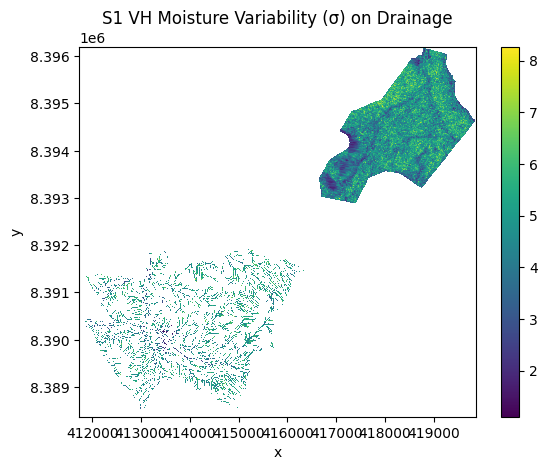

✅ Saved: E:\Hackathon_Picotani_datos_E\7_Chall\hydro_outputs\S1_VH_STD_drain.tif


In [12]:


# --- A4: Apply the aligned mask ---
vh_std_drain = vh_std.where(mask_on_s1)

# --- A5: Visualize and export ---
vh_std_drain.plot(cmap="viridis")
plt.title("S1 VH Moisture Variability (σ) on Drainage")
plt.show()

vh_std_drain.rio.to_raster(str(Path(FLOW_ACC).with_name("S1_VH_STD_drain.tif")))
print("✅ Saved:", Path(FLOW_ACC).with_name("S1_VH_STD_drain.tif"))

In [25]:
import rasterio, glob, os
import numpy as np

S2_DIR = r"G:\Mi unidad\GEE_Biweekly_S2"

# Get first 1–3 files to inspect
sample_files = sorted(glob.glob(os.path.join(S2_DIR, "*_S2_Indices.tif")))[:3]

for f in sample_files:
    print(f"\n🛰️ File: {os.path.basename(f)}")
    with rasterio.open(f) as src:
        print(f"  CRS: {src.crs}")
        print(f"  Size: {src.width} x {src.height}")
        print(f"  Number of bands: {src.count}")
        print("  Bands:")
        for i in range(1, src.count + 1):
            desc = src.descriptions[i-1] if src.descriptions[i-1] else "Unnamed"
            band = src.read(i)
            print(f"    [{i}] {desc}  min={np.nanmin(band):.3f}, max={np.nanmax(band):.3f}")



🛰️ File: 20220101_S2_Indices.tif
  CRS: EPSG:32719
  Size: 813 x 782
  Number of bands: 6
  Bands:
    [1] NDVI  min=-0.197, max=0.729
    [2] OSAVI  min=-0.228, max=0.845
    [3] GNDVI  min=0.003, max=0.636
    [4] CIgreen  min=0.006, max=3.492
    [5] NDWI  min=-0.636, max=-0.003
    [6] NDSVI  min=-0.310, max=0.586

🛰️ File: 20220116_S2_Indices.tif
  CRS: EPSG:32719
  Size: 813 x 782
  Number of bands: 6
  Bands:
    [1] NDVI  min=-0.028, max=0.793
    [2] OSAVI  min=-0.033, max=0.920
    [3] GNDVI  min=0.034, max=0.714
    [4] CIgreen  min=0.071, max=4.992
    [5] NDWI  min=-0.714, max=-0.034
    [6] NDSVI  min=-0.262, max=0.659

🛰️ File: 20220131_S2_Indices.tif
  CRS: EPSG:32719
  Size: 813 x 782
  Number of bands: 6
  Bands:
    [1] NDVI  min=-1.000, max=1.000
    [2] OSAVI  min=-1.146, max=1.159
    [3] GNDVI  min=-0.000, max=1.000
    [4] CIgreen  min=-1.000, max=109.571
    [5] NDWI  min=-1.000, max=0.000
    [6] NDSVI  min=-0.213, max=1.000


Full NDVI stack: (93, 782, 813) 2022-01-01T00:00:00.000000000 → 2025-10-12T00:00:00.000000000
Subset: 2024-07-04T00:00:00.000000000 → 2024-12-31T00:00:00.000000000
✅ NDVI trend saved: S2_NDVI_trend_Jul-Dec2024_fixed.tif
Δ NDVI stats: min = -0.3076604581635893 max = 0.29267912436984966 median = 0.05265992738672634


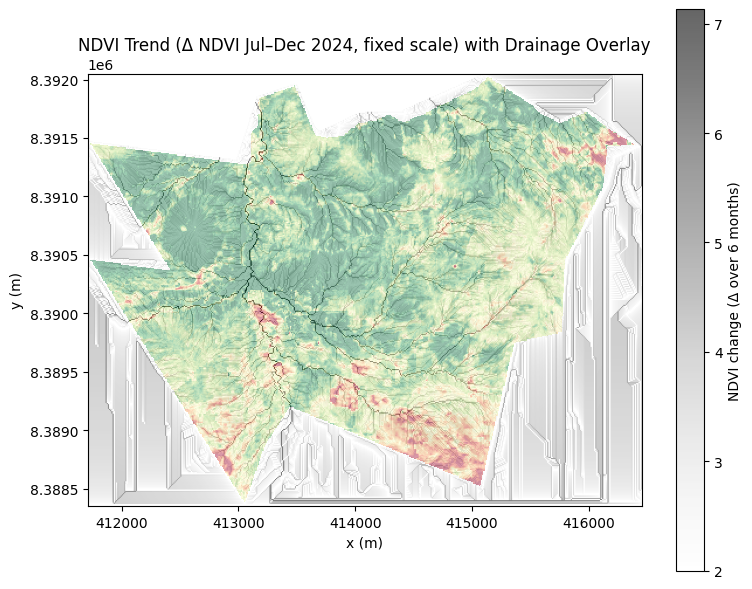

In [33]:
import re, glob, os
import pandas as pd
import rioxarray as rxr, xarray as xr
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
S2_DIR   = r"G:\Mi unidad\GEE_Biweekly_S2"
FLOW_ACC = r"E:\Hackathon_Picotani_datos_E\7_Chall\hydro_outputs\flow_acc.tif"
OUT_TREND = "S2_NDVI_trend_Jul-Dec2024_fixed.tif"

# -----------------------------
# 1️⃣ Load NDVI stack (Sentinel-2)
# -----------------------------
def parse_date_from_name_s2(fp):
    m = re.search(r"(\d{8})_S2", Path(fp).name)
    return pd.to_datetime(m.group(1), format="%Y%m%d") if m else None

s2_files = sorted(glob.glob(os.path.join(S2_DIR, "*_S2_Indices.tif")))
ndvi_stack = []
for f in s2_files:
    d = parse_date_from_name_s2(f)
    if d is None:
        continue
    da = rxr.open_rasterio(f)
    ndvi = da.isel(band=0).squeeze()   # Band 1 = NDVI
    ndvi = ndvi.assign_coords(time=d).expand_dims("time")
    ndvi = ndvi.rio.write_crs("EPSG:32719", inplace=True)
    ndvi_stack.append(ndvi)

s2_ndvi = xr.concat(ndvi_stack, dim="time").sortby("time")
print("Full NDVI stack:", s2_ndvi.shape,
      s2_ndvi.time.values.min(), "→", s2_ndvi.time.values.max())

# -----------------------------
# 2️⃣ Select July–Dec 2024
# -----------------------------
s2_ndvi_sel = s2_ndvi.sel(time=slice("2024-07-01", "2024-12-31"))
print("Subset:", s2_ndvi_sel.time.values.min(), "→", s2_ndvi_sel.time.values.max())

# -----------------------------
# 3️⃣ Compute NDVI trend (fix time scaling)
# -----------------------------
# Convert time coordinate from datetime → numeric days
t0 = s2_ndvi_sel.time.min()
s2_ndvi_sel = s2_ndvi_sel.assign_coords(
    time_days=(s2_ndvi_sel.time - t0) / np.timedelta64(1, "D")
)

# Linear fit of NDVI vs days
coef = s2_ndvi_sel.polyfit(dim="time_days", deg=1)
ndvi_trend_day = coef["polyfit_coefficients"].sel(degree=1)  # slope per day

# Multiply by total number of days in period → total change
days = float((s2_ndvi_sel.time.max() - s2_ndvi_sel.time.min()) / np.timedelta64(1, "D"))
ndvi_trend_period = ndvi_trend_day * days
ndvi_trend_period = ndvi_trend_period.rio.write_crs("EPSG:32719", inplace=True)
ndvi_trend_period.rio.to_raster(OUT_TREND)

print(f"✅ NDVI trend saved: {OUT_TREND}")
print("Δ NDVI stats:",
      "min =", float(ndvi_trend_period.min()),
      "max =", float(ndvi_trend_period.max()),
      "median =", float(ndvi_trend_period.median()))

# -----------------------------
# 4️⃣ Overlay drainage lines from flow accumulation
# -----------------------------
with rasterio.open(OUT_TREND) as src:
    ndvi_arr = src.read(1)
    ndvi_arr[ndvi_arr == src.nodata] = np.nan
    extent = rasterio.plot.plotting_extent(src)

with rasterio.open(FLOW_ACC) as src:
    flow = src.read(1).astype(float)
    flow[flow <= 0] = np.nan
    flow_extent = rasterio.plot.plotting_extent(src)
flow_mask = np.log10(flow)
flow_mask[~np.isfinite(flow_mask)] = np.nan

# -----------------------------
# 5️⃣ Plot NDVI trend + drainage overlay
# -----------------------------
plt.figure(figsize=(8, 6))
norm = TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1)
plt.imshow(ndvi_arr, cmap="RdYlGn", norm=norm, extent=extent)
plt.imshow(flow_mask, cmap="Greys", alpha=0.6, extent=flow_extent)
plt.title("NDVI Trend (Δ NDVI Jul–Dec 2024, fixed scale) with Drainage Overlay")
plt.colorbar(label="NDVI change (Δ over 6 months)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()


Full NDVI stack: (93, 782, 813) 2022-01-01T00:00:00.000000000 → 2025-10-12T00:00:00.000000000
Subset: 2023-07-10T00:00:00.000000000 → 2023-12-22T00:00:00.000000000
✅ NDVI trend saved: S2_NDVI_trend_Jul-Dec2023_fixed.tif
Δ NDVI stats: min = -0.3208918972657274 max = 0.2333439050909773 median = 0.03647623203862883


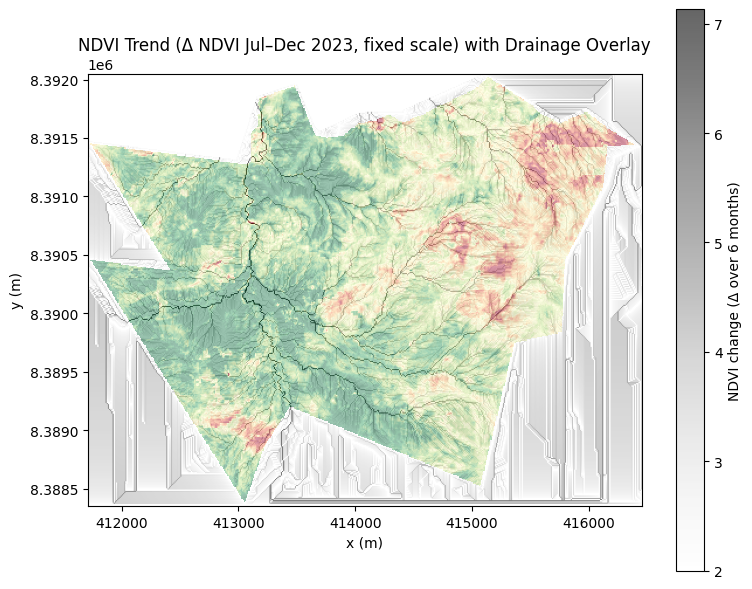

In [35]:
import re, glob, os
import pandas as pd
import rioxarray as rxr, xarray as xr
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
S2_DIR   = r"G:\Mi unidad\GEE_Biweekly_S2"
FLOW_ACC = r"E:\Hackathon_Picotani_datos_E\7_Chall\hydro_outputs\flow_acc.tif"
OUT_TREND = "S2_NDVI_trend_Jul-Dec2023_fixed.tif"

# -----------------------------
# 1️⃣ Load NDVI stack (Sentinel-2)
# -----------------------------
def parse_date_from_name_s2(fp):
    m = re.search(r"(\d{8})_S2", Path(fp).name)
    return pd.to_datetime(m.group(1), format="%Y%m%d") if m else None

s2_files = sorted(glob.glob(os.path.join(S2_DIR, "*_S2_Indices.tif")))
ndvi_stack = []
for f in s2_files:
    d = parse_date_from_name_s2(f)
    if d is None:
        continue
    da = rxr.open_rasterio(f)
    ndvi = da.isel(band=0).squeeze()   # Band 1 = NDVI
    ndvi = ndvi.assign_coords(time=d).expand_dims("time")
    ndvi = ndvi.rio.write_crs("EPSG:32719", inplace=True)
    ndvi_stack.append(ndvi)

s2_ndvi = xr.concat(ndvi_stack, dim="time").sortby("time")
print("Full NDVI stack:", s2_ndvi.shape,
      s2_ndvi.time.values.min(), "→", s2_ndvi.time.values.max())

# -----------------------------
# 2️⃣ Select July–Dec 2024
# -----------------------------
s2_ndvi_sel = s2_ndvi.sel(time=slice("2023-07-01", "2023-12-31"))
print("Subset:", s2_ndvi_sel.time.values.min(), "→", s2_ndvi_sel.time.values.max())

# -----------------------------
# 3️⃣ Compute NDVI trend (fix time scaling)
# -----------------------------
# Convert time coordinate from datetime → numeric days
t0 = s2_ndvi_sel.time.min()
s2_ndvi_sel = s2_ndvi_sel.assign_coords(
    time_days=(s2_ndvi_sel.time - t0) / np.timedelta64(1, "D")
)

# Linear fit of NDVI vs days
coef = s2_ndvi_sel.polyfit(dim="time_days", deg=1)
ndvi_trend_day = coef["polyfit_coefficients"].sel(degree=1)  # slope per day

# Multiply by total number of days in period → total change
days = float((s2_ndvi_sel.time.max() - s2_ndvi_sel.time.min()) / np.timedelta64(1, "D"))
ndvi_trend_period = ndvi_trend_day * days
ndvi_trend_period = ndvi_trend_period.rio.write_crs("EPSG:32719", inplace=True)
ndvi_trend_period.rio.to_raster(OUT_TREND)

print(f"✅ NDVI trend saved: {OUT_TREND}")
print("Δ NDVI stats:",
      "min =", float(ndvi_trend_period.min()),
      "max =", float(ndvi_trend_period.max()),
      "median =", float(ndvi_trend_period.median()))

# -----------------------------
# 4️⃣ Overlay drainage lines from flow accumulation
# -----------------------------
with rasterio.open(OUT_TREND) as src:
    ndvi_arr = src.read(1)
    ndvi_arr[ndvi_arr == src.nodata] = np.nan
    extent = rasterio.plot.plotting_extent(src)

with rasterio.open(FLOW_ACC) as src:
    flow = src.read(1).astype(float)
    flow[flow <= 0] = np.nan
    flow_extent = rasterio.plot.plotting_extent(src)
flow_mask = np.log10(flow)
flow_mask[~np.isfinite(flow_mask)] = np.nan

# -----------------------------
# 5️⃣ Plot NDVI trend + drainage overlay
# -----------------------------
plt.figure(figsize=(8, 6))
norm = TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1)
plt.imshow(ndvi_arr, cmap="RdYlGn", norm=norm, extent=extent)
plt.imshow(flow_mask, cmap="Greys", alpha=0.6, extent=flow_extent)
plt.title("NDVI Trend (Δ NDVI Jul–Dec 2023, fixed scale) with Drainage Overlay")
plt.colorbar(label="NDVI change (Δ over 6 months)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()


In [27]:
print("NDVI stats July–Dec 2024:")
print(" min:", float(s2_ndvi_sel.min()), " max:", float(s2_ndvi_sel.max()))
print("Mean NDVI by date:")
print(s2_ndvi_sel.mean(dim=["x","y"]).to_dataframe(name="NDVI_mean"))

print("\nTrend (×180) stats:")
print(" min:", float(ndvi_trend.min()), " max:", float(ndvi_trend.max()), 
      " median:", float(ndvi_trend.median()))


NDVI stats July–Dec 2024:
 min: -0.12978525459766388  max: 0.7131348848342896
Mean NDVI by date:
            band  spatial_ref  NDVI_mean
time                                    
2024-07-04     1            0   0.269681
2024-07-19     1            0   0.251038
2024-08-03     1            0   0.237871
2024-08-18     1            0   0.230215
2024-09-02     1            0   0.212807
2024-09-17     1            0   0.215285
2024-10-02     1            0   0.198451
2024-10-17     1            0   0.195179
2024-11-01     1            0   0.199378
2024-11-16     1            0   0.242082
2024-12-01     1            0   0.246979
2024-12-16     1            0   0.318585
2024-12-31     1            0   0.339874

Trend (×180) stats:
 min: -3.5608849324489535e-15  max: 3.3874898653915252e-15  median: 6.094899003093568e-16


In [18]:
print(np.nanmin(ndvi_trend.values), np.nanmax(ndvi_trend.values))

-4.9701788965174215e-18 1.8955704332176646e-18


Resolution: (10.0, 10.0)
Min: -32768.0 Max: 13620400.0


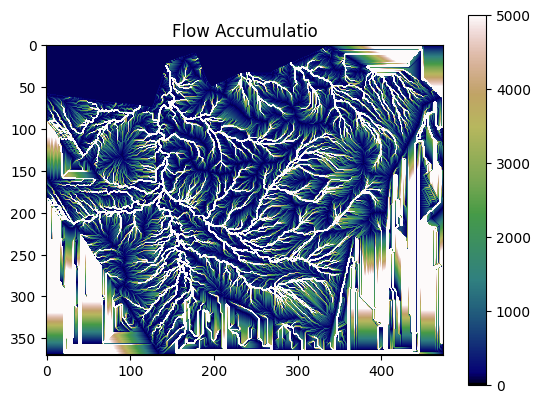

In [ ]:

with rasterio.open(os.path.join(out_dir, "flow_acc.tif")) as src:
    arr = src.read(1)
    plt.imshow(src.read(1), cmap="gist_earth", vmin=0, vmax=5000)
    print("Resolution:", src.res)
    print("Min:", arr.min(), "Max:", arr.max())
    plt.title("Flow Accumulatio")
    plt.colorbar()
    plt.show()
    
with rasterio.open(os.path.join(out_dir, "filled.tif")) as src:
    arr = src.read(1)
    plt.figure(figsize=(8,6))
    plt.imshow(arr, cmap="terrain")
    plt.title("Filled DEM (elevation in m)")
    plt.colorbar(label="Elevation (m)")
    plt.show()

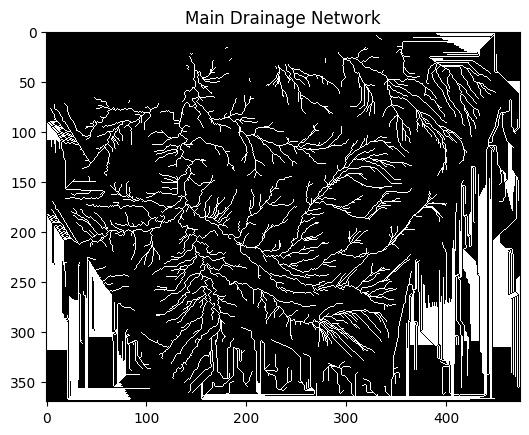

In [45]:
import numpy as np

with rasterio.open(os.path.join(out_dir, "flow_acc.tif")) as src:
    acc = src.read(1)
    profile = src.profile
# Mask small accumulation values
stream_mask = (acc > 5000).astype(np.uint8)  # adjust threshold
plt.imshow(stream_mask, cmap="gray")
plt.title("Main Drainage Network")
plt.show()

In [46]:
import geopandas as gpd
from shapely.geometry import LineString

contours = measure.find_contours(stream_mask, 0.5)
gdf = gpd.GeoDataFrame(geometry=[LineString(c[:, ::-1]) for c in contours], crs=profile["crs"])
gdf.to_file("streams_main.shp")

In [ ]:
import xarray as xr
import numpy as np

ds = xr.open_mfdataset("S1_biweekly_*.tif", concat_dim="time")
vh = ds.vh  # adjust band name
vh_std = vh.std(dim="time")

vh_std.plot(cmap="viridis")
plt.title("Sentinel-1 Wetness Variability (Jun–Dec 2024)")

vh_std_masked = vh_std.where(acc > 5000)
vh_std_masked.plot(cmap="viridis")
plt.title("Moisture Variability along Drainage Lines")

In [ ]:
ndvi = xr.open_mfdataset("S2_NDVI_*.tif", concat_dim="time")["ndvi"]
ndvi_trend = ndvi.polyfit(dim="time", deg=1)["polyfit_coefficients"].sel(degree=1)

# classify pixels by flow accumulation
drain = acc > 5000
upland = acc < 50

trend_drain = float(ndvi_trend.where(drain).mean())
trend_upland = float(ndvi_trend.where(upland).mean())
print("NDVI trend (drain):", trend_drain, " NDVI trend (upland):", trend_upland)

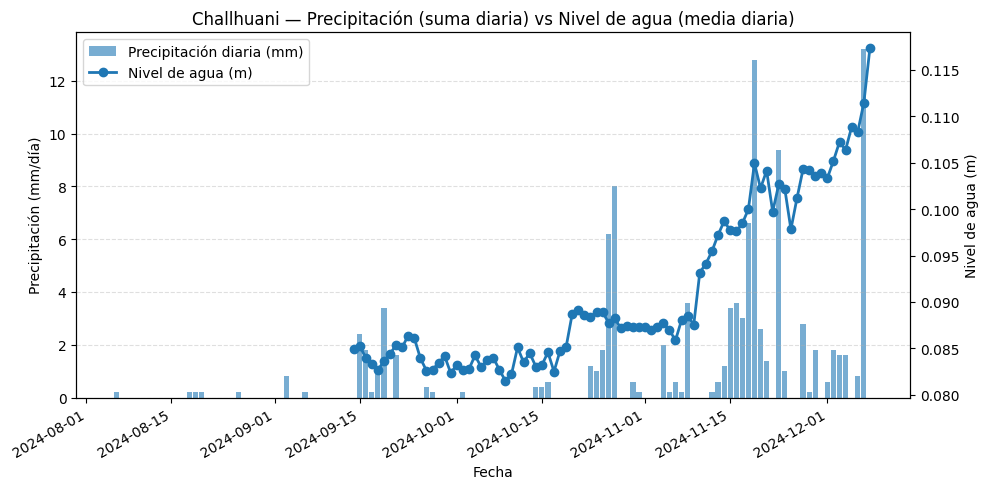

Merged daily data saved to: challhuani_daily_precip_waterlevel.csv


In [16]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# -----------------------------
# File paths (as provided)
# -----------------------------
CLIMATE_XLSX = r"precipitation_waterlevel\01 Data Climatic variables in the Challhuani.xlsx"
WLEVEL_XLSX  = r"precipitation_waterlevel\01_Data_ Water Level of Hydrological Stations.xlsx"

# -----------------------------
# Helpers
# -----------------------------
def fix_decimal(x):
    """Convert strings with comma/space/etc. to float, keep NaN on failure."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace('\u00a0', ' ').replace(',', '.')
    if s == '' or s.lower() in {'na', 'nan', 'none'}:
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def parse_date_flexible(series):
    """
    Parse 'd/m/yyyy' where day and/or month may lack leading zeros.
    We rely on dayfirst parsing and strip spaces. No time-of-day.
    """
    s = series.astype(str).str.strip().str.replace('\u00a0', ' ', regex=False)
    # Normalize any accidental double slashes or spaces around slashes
    s = s.str.replace(r'\s*/\s*', '/', regex=True)
    # Use dayfirst; do NOT pass a strict format so single-digit d/m is accepted
    return pd.to_datetime(s, errors='coerce')

# -----------------------------
# Load Climate (Challhuani station) — uses Date + Time columns
# -----------------------------
# If the sheet name is unknown, sheet_name=0 (first sheet) usually works.
clim = pd.read_excel(
    CLIMATE_XLSX,
    dtype=str  # read as strings first; we'll clean numerics
)

# Clean column names lightly
clim.columns = [c.strip().replace('\u00a0', ' ') for c in clim.columns]

# Expecting columns: Date, Time, Precipitation_mm, ...
# Parse the Date only (ignore time-of-day in the aggregation as requested).
clim['Date'] = parse_date_flexible(clim['Date'])
clim['Precipitation_mm'] = clim['Precipitation_mm'].apply(fix_decimal)

# Add an explicit 'date' column to avoid unnamed group issue
clim['date'] = pd.to_datetime(clim['Date'].dt.date)  # make sure it's datetime64
clim_daily = (
    clim
    .dropna(subset=['date'])
    .groupby('date', as_index=False)['Precipitation_mm']
    .sum()
    .rename(columns={'Precipitation_mm': 'precip_mm'})
)

clim_daily['date'] = pd.to_datetime(clim_daily['date'])  # ensure datetime64[ns]

# -----------------------------
# Load Water Level — uses Date + Hour + Monitoring_site
# -----------------------------
wlev = pd.read_excel(
    WLEVEL_XLSX,
    sheet_name=0,
    dtype=str
)
wlev.columns = [c.strip().replace('\u00a0', ' ') for c in wlev.columns]

# Filter to Monitoring_site == "Challhuani"
if 'Monitoring_site' not in wlev.columns:
    raise ValueError("Column 'Monitoring_site' not found in water level file.")
wlev = wlev[wlev['Monitoring_site'].astype(str).str.strip().str.lower() == 'challhuani']

# Parse date (ignore Hour in the aggregation as requested)
if 'Date' not in wlev.columns:
    raise ValueError("Column 'Date' not found in water level file.")
wlev['Date'] = parse_date_flexible(wlev['Date'])
wlev['Water_level_m'] = wlev['Water_level_m'].apply(fix_decimal)
wlev['date'] = wlev['Date'].dt.date
wlev['date'] = pd.to_datetime(wlev['Date'].dt.date)  # ensure datetime64
wlev_daily = (
    wlev
    .dropna(subset=['date'])
    .groupby('date', as_index=False)['Water_level_m']
    .mean()
    .rename(columns={'Water_level_m': 'water_level_m'})
)

# -----------------------------
# Merge daily series on date
# -----------------------------
daily = pd.merge(clim_daily, wlev_daily, on='date', how='outer').sort_values('date')
# Optional: forward/back fill water level if desired — comment/uncomment as needed
# daily['water_level_m'] = daily['water_level_m'].interpolate(limit_direction='both')

# Save merged daily to CSV for inspection
daily.to_csv('challhuani_daily_precip_waterlevel.csv', index=False)

# -----------------------------
# Plot: dual-axis time series
# -----------------------------
plt.figure(figsize=(10, 5))
ax1 = plt.gca()

# Bars for precipitation (mm)
ax1.bar(daily['date'], daily['precip_mm'], width=0.85, align='center', alpha=0.6, label='Precipitación diaria (mm)')
ax1.set_ylabel('Precipitación (mm/día)')
ax1.set_xlabel('Fecha')
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)

# Line for mean daily water level (m) on a secondary axis
ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['water_level_m'], marker='o', linewidth=2, label='Nivel de agua (m)', zorder=5)
ax2.set_ylabel('Nivel de agua (m)')

# Title and legend handling
plt.title('Challhuani — Precipitación (suma diaria) vs Nivel de agua (media diaria)')
# Build a combined legend
lines_labels = []
for ax in [ax1, ax2]:
    lines, labels = ax.get_legend_handles_labels()
    lines_labels += list(zip(lines, labels))
by_label = dict(lines_labels)
plt.legend(by_label.keys(), by_label.values(), loc='upper left')

# Improve x ticks (dates only; no time)
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

print("Merged daily data saved to: challhuani_daily_precip_waterlevel.csv")


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- File paths ---
CLIMATE_XLSX = r"precipitation_waterlevel\01 Data Climatic variables in the Challhuani.xlsx"
WLEVEL_XLSX  = r"precipitation_waterlevel\01_Data_ Water Level of Hydrological Stations.xlsx"

# ---------- CLIMATE (daily precip) ----------
clim = pd.read_excel(CLIMATE_XLSX)
clim.columns = [c.strip().replace(' ', '_') for c in clim.columns]

# Pick the precipitation column robustly (handles slight header variations)
precip_col = None
for c in clim.columns:
    lc = c.lower()
    if 'precip' in lc:         # e.g., 'Precipitation_mm', 'Precipitacion', etc.
        precip_col = c
        break
if precip_col is None:
    raise ValueError("No precipitation column found. Check the headers in the climate file.")

# Parse Date only (works with 9/8/2024 and 09/08/2024)
clim['Date'] = pd.to_datetime(clim['Date'].astype(str),
                              dayfirst=True, errors='coerce', infer_datetime_format=True)
clim = clim.dropna(subset=['Date'])

# Ensure numeric precipitation
clim[precip_col] = pd.to_numeric(clim[precip_col], errors='coerce').fillna(0.0)

# Daily aggregation (sum)
daily_clim = (clim
              .groupby(clim['Date'].dt.normalize(), as_index=False)[precip_col]
              .sum()
              .rename(columns={precip_col: 'Precip_mm'}))

# ---------- WATER LEVEL (daily mean) ----------
water = pd.read_excel(WLEVEL_XLSX)
water.columns = [c.strip().replace(' ', '_') for c in water.columns]

# Keep only Challhuani
water = water[water['Monitoring_site'].astype(str).str.contains('Challhuani', case=False, na=False)]

# Parse Date only
water['Date'] = pd.to_datetime(water['Date'].astype(str),
                               dayfirst=True, errors='coerce', infer_datetime_format=True)
water = water.dropna(subset=['Date'])

# Ensure numeric water level
water['Water_level_m'] = pd.to_numeric(water['Water_level_m'], errors='coerce')

# Daily aggregation (mean)
daily_wl = (water
            .groupby(water['Date'].dt.normalize(), as_index=False)['Water_level_m']
            .mean()
            .rename(columns={'Water_level_m': 'WaterLevel_m'}))

# ---------- (Optional) align date ranges & fill gaps ----------
# Build a full daily index that spans both series
start = min(daily_clim['Date'].min(), daily_wl['Date'].min())
end   = max(daily_clim['Date'].max(), daily_wl['Date'].max())
full_days = pd.date_range(start, end, freq='D')

daily_clim = (daily_clim.set_index('Date')
                        .reindex(full_days)
                        .rename_axis('Date')
                        .fillna({'Precip_mm': 0.0})
                        .reset_index())

daily_wl = (daily_wl.set_index('Date')
                    .reindex(full_days)
                    .rename_axis('Date')
                    .reset_index())   # WaterLevel_m left as NaN if no readings

# ---------- Plot separately ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Precipitation (bars)
ax1.bar(daily_clim['Date'], daily_clim['Precip_mm'], alpha=0.75)
ax1.set_ylabel("Precipitación diaria (mm)")
ax1.set_title("Precipitación diaria - Challhuani")
ax1.grid(True, linestyle='--', alpha=0.4)

# Water level (line)
ax2.plot(daily_wl['Date'], daily_wl['WaterLevel_m'], marker='o', linewidth=1.4)
ax2.set_ylabel("Nivel del agua (m)")
ax2.set_title("Nivel medio diario del agua - Challhuani")
ax2.grid(True, linestyle='--', alpha=0.4)

plt.xlabel("Fecha")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_3792\1464365266.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  clim['Date'] = pd.to_datetime(clim['Date'].astype(str),
C:\Users\user\AppData\Local\Temp\ipykernel_3792\1464365266.py:33: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .sum()
C:\Users\user\AppData\Local\Temp\ipykernel_3792\1464365266.py:44: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.htm

KeyError: 'Date'

In [7]:
print(clim['Precipitation_mm'].describe())
print("Nonzero precipitation rows:", (clim['Precipitation_mm'] > 0).sum())
print("Total rows:", len(clim))

count    1319.000000
mean        0.000758
std         0.012295
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.200000
Name: Precipitation_mm, dtype: float64
Nonzero precipitation rows: 5
Total rows: 1319


In [62]:
print(df.head())

Empty DataFrame
Columns: [Precipitation_mm, Water_level_m]
Index: []
